# House Price Prediction
Week 1 Internship Project — Regression model to predict house prices and identify key influencing features.

## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (545, 13)


In [4]:
print("Target column: price")
print("Feature columns:", [c for c in df.columns if c != 'price'])

Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [5]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Task 2 — Data Cleaning

In [6]:
# Fill numeric missing values with median (robust to outliers), categorical with mode
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()  # should be 0 now

np.int64(0)

In [7]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows. New shape: {df.shape}")

Removed 0 duplicate rows. New shape: (545, 13)


In [8]:
# Convert binary yes/no columns to 0/1
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encode the multi-category column
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [9]:
# All remaining columns are numeric and meaningful for predicting price — keep all
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    b

## Task 3 — Model Building

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 436 rows | Test: 109 rows


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print(f"MAE:  {mae_lr:,.0f}")
print(f"RMSE: {rmse_lr:,.0f}")
print(f"R2:   {r2_lr:.3f}")

Linear Regression Performance
MAE:  970,043
RMSE: 1,324,507
R2:   0.653


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Performance")
print(f"MAE:  {mae_rf:,.0f}")
print(f"RMSE: {rmse_rf:,.0f}")
print(f"R2:   {r2_rf:.3f}")

Random Forest Regressor Performance
MAE:  1,014,947
RMSE: 1,399,769
R2:   0.612


In [16]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


## Task 4 — Visualization

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('charts', exist_ok=True)
sns.set_style('whitegrid')

### Chart 1: Distribution of House Prices

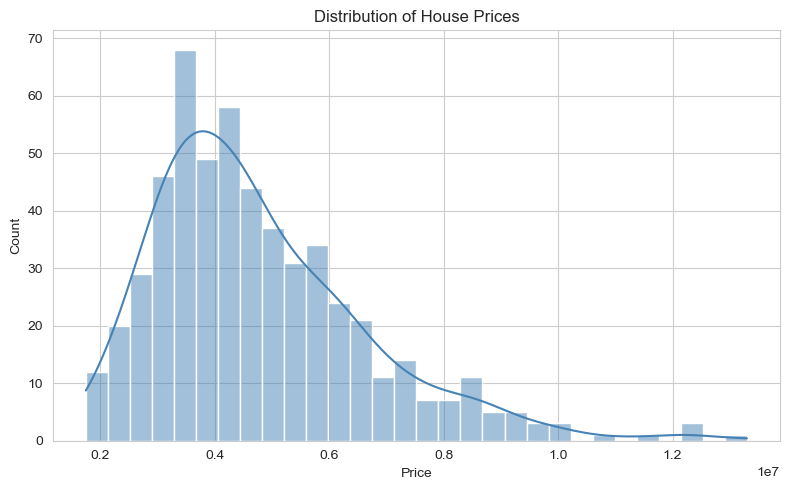

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True, color='steelblue', bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()

### Chart 2: Correlation Heatmap

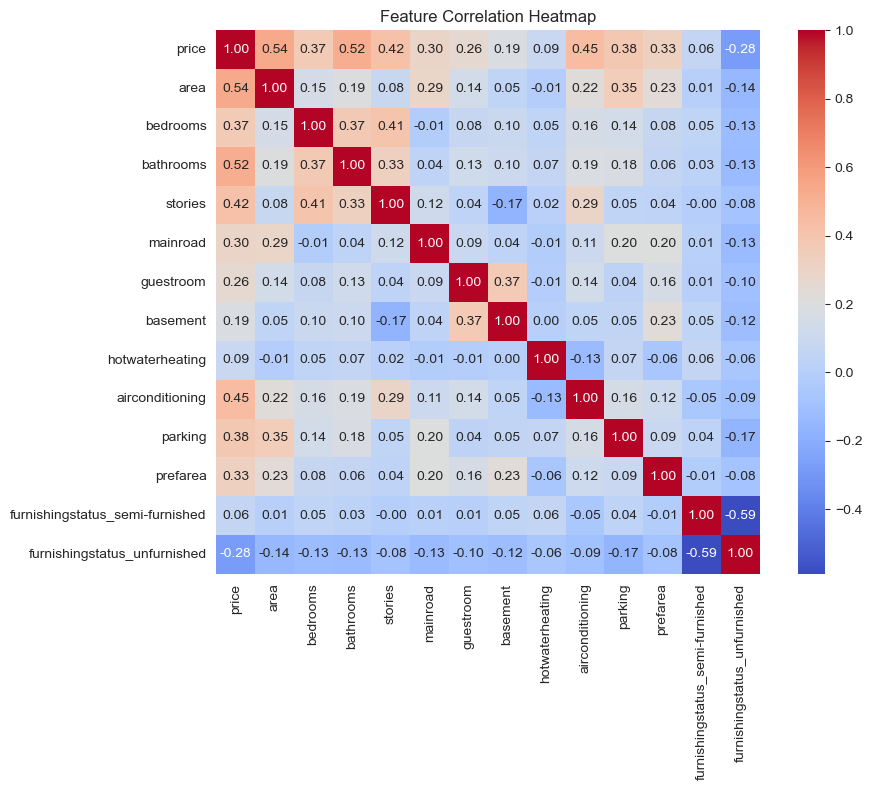

In [19]:
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()

### Chart 3: Actual vs Predicted Price (Random Forest)

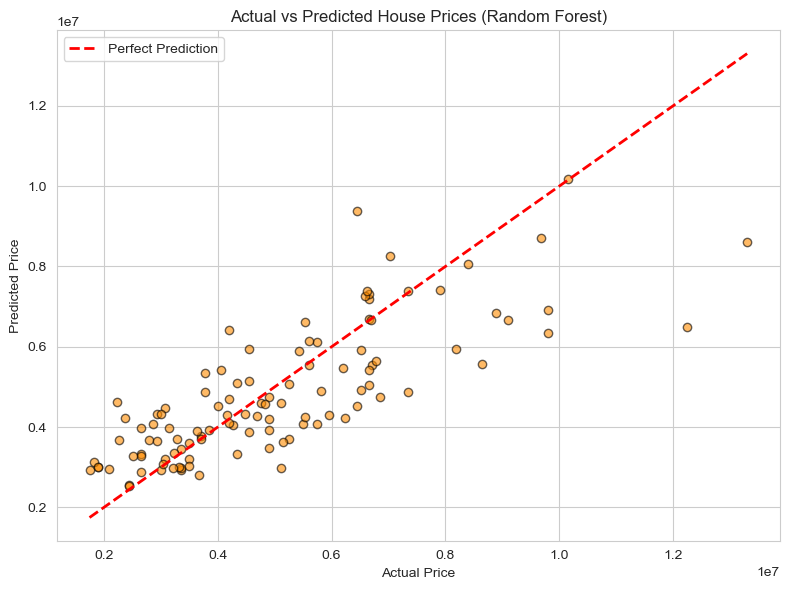

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='darkorange', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices (Random Forest)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()

## Task 5 — Insights & Summary

In [21]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top features influencing price (Random Forest importance):")
feature_importance.head(6)

Top features influencing price (Random Forest importance):


area               0.467809
bathrooms          0.152635
airconditioning    0.060260
parking            0.057557
stories            0.057045
bedrooms           0.047544
dtype: float64

#### Summary

This dataset has 545 houses with 13 columns. The price histogram shows most houses fall between 2-6 million, with fewer expensive outliers above 8 million — so the data is right-skewed, not evenly spread. From the correlation heatmap, area, bathrooms, and air conditioning came out as the strongest factors tied to price. Accuracy-wise, the model isn't great — average error (MAE) is around 9.7 lakh, and the actual-vs-predicted scatter plot shows a lot of scatter around the line instead of a tight fit, especially for cheap and very expensive houses where it's noticeably off. What surprised me was Linear Regression beating Random Forest (R² 0.65 vs 0.61) — I expected the "smarter" model to win, but with only 545 rows there isn't enough data for Random Forest's complexity to pay off. For a real estate business, I'd say use this model as a rough starting estimate only, not a final price — and double-check the high and low ends manually since that's where it's least reliable.